In [2]:
#Questão 1

class MedidaPrecisa:
    def __init__(self, m):
        self.mm = int(m*1000)

    def metros(self):
        return self.mm / 1000

    def __add__(self, other):
        new = MedidaPrecisa(0)
        new.mm = self.mm + other.mm
        
        return new

    def __sub__(self, other):
        new = MedidaPrecisa(0)
        new.mm = self.mm - other.mm

        return new
    
    def __str__(self):
        return f'{self.metros()}m'
    
num1 = MedidaPrecisa(1056.004)
num2 = MedidaPrecisa(1054.002)

print(num1)
print(num2)

print(num1 + num2)
print(num2 + num1)

print(num1 - num2)
print(num2 - num1)


1056.004m
1054.002m
2110.006m
2110.006m
2.002m
-2.002m


### Discussão:
- Multipliquei a entrada padrão de metros por 1000, para usar a precisão de int para milímetro
- Os valores ainda podem chegar a centenas de quilômetros


In [ ]:
#Código para questão 2

from typing import Any
import numpy as np
import matplotlib.  pyplot as plt
    
class Domain:
    min = None
    max = None

    def __contains__(self, x):
        raise NotImplementedError
    
    def __repr__(self):
        raise NotImplementedError

    def __str__(self):
        return self.__repr__()
    
    def copy(self):
        raise NotImplementedError 


class Interval(Domain):
    def __init__(self, p1, p2):
        self.inff, self.supp = min(p1, p2), max(p1, p2)
    
    @property
    def min(self):
        return self.inff

    @property
    def max(self):
        return self.supp
    
    @property
    def size(self):
        return (self.max - self.min)
    
    @property
    def haf(self):
        return (self.max + self.min)/2.0
    
    def __contains__(self, x):
        return  np.all(np.logical_and(self.inff <= x, x <= self.supp))

    def __str__(self):
        return f'[{self.inff:2.4f}, {self.supp:2.4f}]' 

    def __repr__(self):
        return f'[{self.inf!r:2.4f}, {self.supp!r:2.4f}]'
    
    def copy(self):
        return Interval(self.inff, self.supp)


class RealFunction:
    f = None
    prime = None
    domain = None   
    
    def eval_safe(self, x):
        if self.domain is None or x in self.domain:
            return self.f(x)
        else:
            raise Exception("The number is out of the domain")

    def prime_safe(self, x):
        if self.domain is None or x in self.domain:
            return self.prime(x)
        else:
            raise Exception("The number is out of the domain")
        
    def __call__(self, x) -> float:
        return self.eval_safe(x)
    
    def plot(self):
        fig, ax = plt.subplots()
        X = np.linspace(self.domain.min, self.domain.max, 100)
        Y = self(X)
        ax.plot(X,Y)
        return fig, ax



def bissect(f: RealFunction, 
            search_space: Interval, 
            erroTol: float = 1e-4, 
            maxItr: int = 1e4, 
            eps: float = 1e-6 ) -> Interval:
    count = 0
    ss = search_space.copy()
    err = ss.size/2.0
    fa, fb = f(ss.min), f(ss.max)
    if fa * fb > -eps:
        if abs(fa) < eps:
            return Interval(ss.min, ss.min)
        elif abs(fb) < eps:
            return Interval(ss.max, ss.max)
        else:
            raise Exception("The interval extremes share the same signal;\n employ the grid search method to locate a valid interval.")
    while count <= maxItr and err > erroTol:
        count += 1
        a, b, m =  ss.min, ss.max, ss.haf
        fa, fb, fm = f(a), f(b), f(m)
        if abs(fm) < eps:
            return Interval(m, m)
        elif fa * fm < -eps:
            ss = Interval(a, m)
        elif fb * fm < -eps:
            ss = Interval(m, b)
    return ss


def grid_search(f: RealFunction, domain: Interval = None, grid_freq = 8) -> Interval:
    if domain is not None:
        D = domain.copy()
    else:
        D = f.domain.copy()
    L1 = np.linspace(D.min, D.max, grid_freq)
    FL1 = f(L1)
    TI = FL1[:-1]*FL1[1:]
    VI = TI <= 0
    if not np.any(VI):
        return None
    idx = np.argmax(VI)
    return Interval(L1[idx], L1[idx+1])

[-4.9386, -4.9385]
Raiz por newton_root (começando em -4.666666666666666): -0.5827319886556126


'\nAcham valores diferentes, mas todos raízes.\n'

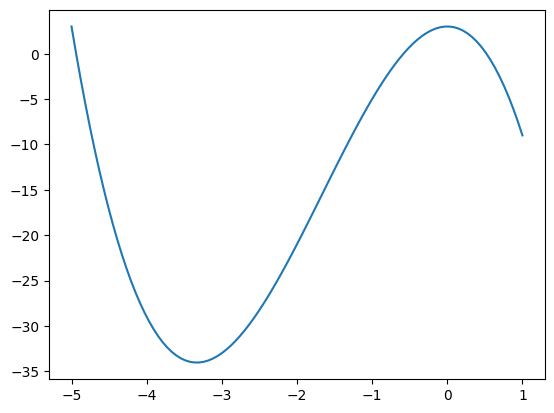

In [4]:
#Questão 2
def newton_root(funcao: RealFunction, x0: float, tol: float = 1e-6, max_iter: int = 100) -> float:
    raiz = x0

    if funcao.prime is not None:
        df = funcao.prime_safe 
    else:
        h = 1e-8
        df = lambda x: (funcao(x+h) - funcao(x))/ h 
    
    for _ in range(max_iter):
        y = funcao(raiz)
        dy = df(raiz)
        
        #convergência
        if abs(y) < tol:
            return raiz

        #divisão por 0
        if abs(dy) < 1e-12:
            print('Derivada muito próxima de 0!')
            return None

        nova_raiz = raiz - y/dy

        if abs(nova_raiz - raiz) < tol:
            return nova_raiz
        
        raiz = nova_raiz

    return raiz


#herdando RealFunction para criar uma função como 'objeto', possuindo características
class funcTest(RealFunction):
    f = lambda self, x : -2*np.power(x, 3) - 10*np.power(x, 2) + 3
    prime = lambda self, x : 6*np.power(x, 2) - 20*x
    domain = Interval(-5, 1)

#aplicando numa variável
ft = funcTest()

#criando 'New Domain', o qual é um subconjunto do Domain da função, buscado com grid search, para diminuir o intervalo onde está a raiz.

NewDomain = grid_search( ft, grid_freq=10)

#utilizando a função bissect para encontrar a raiz dentro de new domain (dividir para conquistar)
print(bissect(ft, search_space=NewDomain))

#definindo o ponto médio de New Domain como o hute inicial para o método newton, o qual calcula de acordo com a derivada.
chute = NewDomain.haf 
raiz_newton = newton_root(ft, chute)
print(f"Raiz por newton_root (começando em {chute}): {raiz_newton}")

#método de plot da função, para visualizá-la
ft.plot()

'''
Acham valores diferentes, mas todos raízes.
'''

In [5]:
#Código para questão 3:
# Python 3
import numpy as np


class interpolater:

    def evaluate(self, X):
        raise NotImplementedError

    def __call__(self,  X):
        return self.evaluate(X)


class VandermondeMatrix(interpolater):
    def __init__(self, x, y):
        if len(x) != len(y):
            raise RuntimeError(f"Dimensions must be equal len(x) = {len(x)} != len(y) = {len(y)}")
        self.data = [x, y]
        self._degree = len(x) -1
        self._buildMatrix()
        self._poly = np.linalg.solve(self.matrix, self.data[1])

    def _buildMatrix(self):
        self.matrix = np.ones([self._degree+1, self._degree+1])
        for i, x in enumerate(self.data[0]):
            self.matrix[i, 1:] = np.multiply.accumulate(np.repeat(x, self._degree))
    
    def evaluate(self, X):
        r = 0.0
        for c in self._poly[::-1]:
            r = c+r*X
        return r


def random_sample(intv, N):
    r = np.random.uniform(intv[0], intv[1], N-2)
    r.sort()
    return np.array([intv[0]] + list(r) + [intv[1]])

def error_pol(f, P, intv, n = 1000):
    x = random_sample(intv, n)
    vectError = np.abs(f(x)-P(x))
    return np.sum(vectError)/n, np.max(vectError)


<IPython.core.display.Math object>

Tempo para Vandermonde: 0.0004487510013859719s


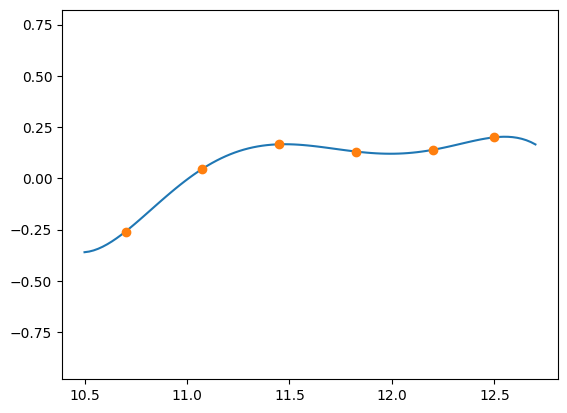

Tempo para Lagrange: 0.002563922000263119s


<IPython.core.display.Math object>

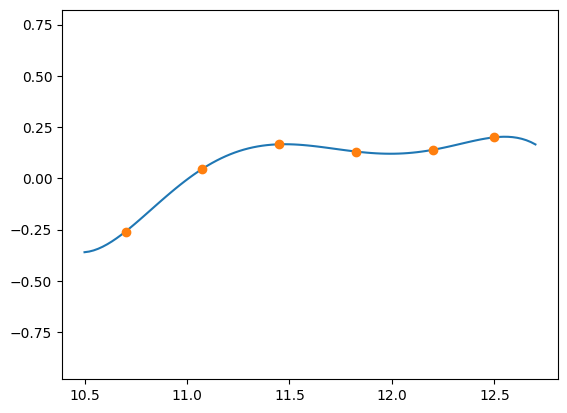

Vandermonde é ≈6 vezes mais rápido que Lagrange, para a entrada atual
Pode variar a cada rodagem.


In [6]:
#Questão 3
from scipy.interpolate import lagrange
from time import perf_counter as cronometro
import sympy as sp
from IPython.display import Math
x_sym = sp.symbols('x')


class Lagrange(interpolater):
    def __init__(self, x, y):
        if len(x) != len(y):
            raise RuntimeError(f"Dimensions must be equal len(x) = {len(x)} != len(y) = {len(y)}")
        self.data_x = x
        self.data_y = y
        self._poly = self._build_poly()

    def _build_poly(self):
        return lagrange(self.data_x, self.data_y)

    def evaluate(self, X):
        return self._poly(X)
    
    def __str__(self):
        return f'Polinômio: {self._poly}'



import matplotlib.pyplot as plt

DataX = [10.7       , 11.075     , 11.45      , 11.825     , 12.2       , 12.5]
DataY = [-0.25991903,  0.04625002,  0.16592075,  0.13048074,  0.13902777, 0.2]

i = cronometro()
Pvm = VandermondeMatrix(DataX, DataY)
f = cronometro()

#print bonito
coefs_sym = [sp.Float(c, 4) for c in Pvm._poly[::-1]]
polinomio_sympy = sp.Poly(coefs_sym, x_sym).as_expr()
display(Math(f"P(x) = {sp.latex(polinomio_sympy)}"))

t1 = f-i
print(f'Tempo para Vandermonde: {t1}s')

X = np.linspace(min(DataX)-0.2, max(DataX)+0.2, 100)
Y = Pvm(X)

_, ax = plt.subplots(1)
ax.plot(X,Y)
ax.axis('equal')
ax.plot(DataX, DataY, 'o')
plt.show()

i = cronometro()
Pol = Lagrange(DataX, DataY)
f = cronometro()

t2 = f-i
print(f'Tempo para Lagrange: {t2}s')


Y = Pol(X)

#print bonito
pol_sp = sp.Poly(Pol._poly.coef, x_sym).as_expr()
display(Math(f'P(x) = {sp.latex(pol_sp)}'))

_, ax = plt.subplots(1)
ax.plot(X,Y)
ax.axis('equal')
ax.plot(DataX, DataY, 'o')
plt.show()

print(f'Vandermonde é ≈{round(t2/t1)} vezes mais rápido que Lagrange, para a entrada atual\nPode variar a cada rodagem.')


'Polinômio Lagrange = '

<IPython.core.display.Math object>

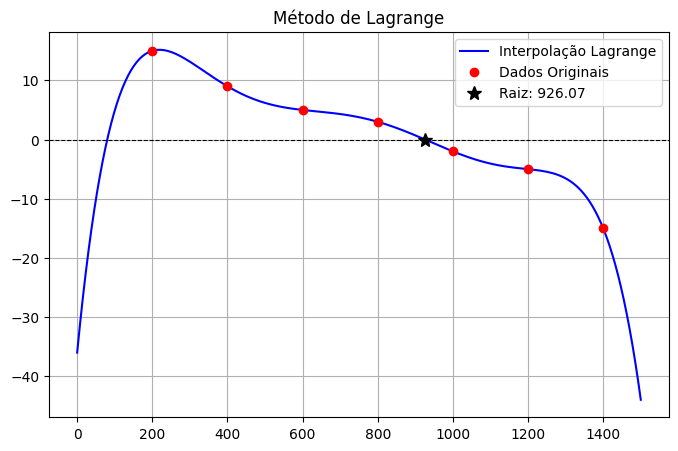

'Polinômio Vandermonde = '

<IPython.core.display.Math object>

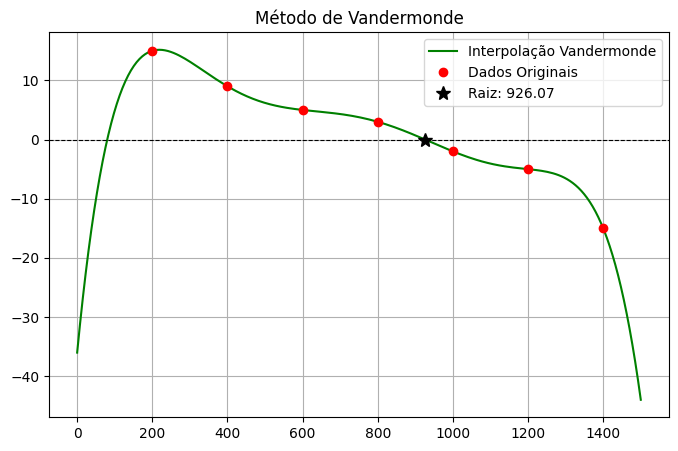

'Spline Cúbica (interp1d) = '

'Não representável por polinômio sympy'

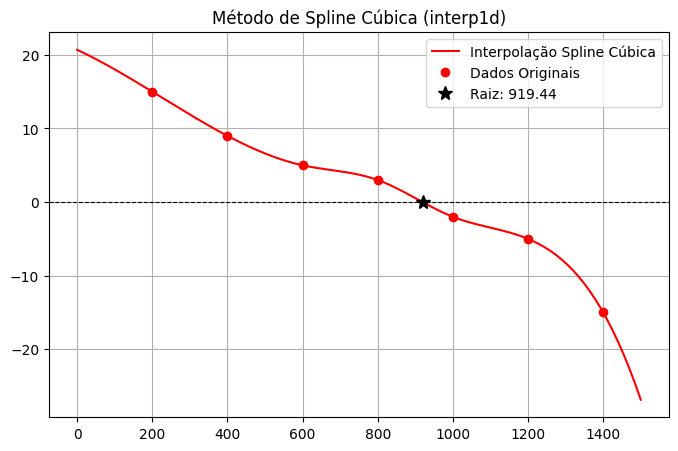

Altura para 0°C com vandermonde = 80.06045692845396 ou 926.0676656404554, Média entre raízes = 503.0640612844547
Altura para 0°C com lagrange = 80.06045692845396 ou 926.0676656405076, Média entre raízes = 503.0640612844808
Altura para 0°C com spline = 919.382195723684 ou 919.442940919213, Média entre raízes = 919.4125683214486

Temperatura para 700m (vandermonde): 4.311523437497783°C
Temperatura para 700m (lagrange): 4.311523437500327°C
Temperatura para 700m (spline): 4.181919642857143°C


In [11]:
#Questão 4 (Rodar códigos anteriores, por favor)
from scipy.interpolate import interp1d
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

x_sym = sp.symbols('x') # Adicionado para garantir que x_sym exista

x_data = [200, 400, 600, 800, 1000, 1200, 1400]
y_data = [15, 9, 5, 3, -2, -5, -15]


#interpolações
Plg = Lagrange(x_data, y_data)
Pvm = VandermondeMatrix(x_data, y_data)
# MODIFICADO: Adicionado fill_value para permitir a busca de raiz e plot no domínio [0, 1500]
Plp = interp1d(x_data, y_data, 'cubic', fill_value="extrapolate") 

#print bonito
pol_sp = sp.Poly(Plg._poly.coef, x_sym).as_expr()
display(f'Polinômio Lagrange = ', Math(str(sp.latex(pol_sp))))

class FuncLagrange(RealFunction):
    f = Plg
    prime = f._poly.deriv()
    domain = Interval(0, 1500)

Poly_Lag = FuncLagrange()
#Raízes para lagrange
ND = grid_search(Poly_Lag, grid_freq=20)
raiz_l_b = bissect(Poly_Lag, ND)

#chute = (ND.max + ND.haf)/2
chute = x_data[-3]
raiz_l_n = newton_root(Poly_Lag, chute, max_iter=500)

X_plot = np.linspace(0, 1500, 200)#Domínio de plotagem

#Gráfico Lagrange (IA)
plt.figure(figsize=(8, 5))
plt.plot(X_plot, Poly_Lag.f(X_plot), label='Interpolação Lagrange', color='blue')
plt.plot(x_data, y_data, 'ro', label='Dados Originais')
if raiz_l_n:
    plt.plot(raiz_l_n, 0, 'k*', markersize=10, label=f'Raiz: {raiz_l_n:.2f}')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title("Método de Lagrange")
plt.legend()
plt.grid(True)
plt.show()

#-------------------------------------------------------------

#print bonito
coefs_sym = [sp.Float(c, 4) for c in Pvm._poly[::-1]]
polinomio_sympy = sp.Poly(coefs_sym, x_sym).as_expr()
display(f'Polinômio Vandermonde = ', Math(str(sp.latex(polinomio_sympy))))

class FuncVandermonde(RealFunction):
    f = Pvm
    prime = np.poly1d(f._poly[::-1]).deriv()
    domain = Interval(0, 1500)

Poly_Vmd = FuncVandermonde()
#Raízes para Vandermonde
ND_vmd = grid_search(Poly_Vmd, grid_freq=20)
raiz_v_b = bissect(Poly_Vmd, ND_vmd)

chute_vmd = (ND_vmd.max + ND_vmd.haf)/2
raiz_v_n = newton_root(Poly_Vmd, chute, max_iter=500)


# Gráfico Vandermonde (IA)
plt.figure(figsize=(8, 5))
plt.plot(X_plot, Poly_Vmd.f(X_plot), label='Interpolação Vandermonde', color='green')
plt.plot(x_data, y_data, 'ro', label='Dados Originais')
if raiz_v_n:
    plt.plot(raiz_v_n, 0, 'k*', markersize=10, label=f'Raiz: {raiz_v_n:.2f}')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title("Método de Vandermonde")
plt.legend()
plt.grid(True)
plt.show()

#-----------------------------------------------------------------------

display(f'Spline Cúbica (interp1d) = ', "Não representável por polinômio sympy")

class FuncInterp1d(RealFunction):
    f = Plp
    prime = None #Newton_root usará a derivada numérica interna
    domain = Interval(0, 1500)

Poly_Plp = FuncInterp1d()
#Raízes para interp1d
ND_plp = grid_search(Poly_Plp, grid_freq=20)
raiz_p_b = bissect(Poly_Plp, ND_plp)

chute_plp = (ND_plp.max + ND_plp.haf)/2
raiz_p_n = newton_root(Poly_Plp, chute, max_iter=500)

#Gráfico Spline Cúbica (interp1d)
plt.figure(figsize=(8, 5))
plt.plot(X_plot, Poly_Plp.f(X_plot), label='Interpolação Spline Cúbica', color='red')
plt.plot(x_data, y_data, 'ro', label='Dados Originais')
if raiz_p_n:
    plt.plot(raiz_p_n, 0, 'k*', markersize=10, label=f'Raiz: {raiz_p_n:.2f}')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title("Método de Spline Cúbica (interp1d)")
plt.legend()
plt.grid(True)
plt.show()

#-----------------------------------------------------------------------

#item a)
print(f'Altura para 0°C com vandermonde = {raiz_v_b.haf} ou {raiz_v_n}, Média entre raízes = {(raiz_v_n+raiz_v_b.haf)/2}')
print(f'Altura para 0°C com lagrange = {raiz_l_b.haf} ou {raiz_l_n}, Média entre raízes = {(raiz_l_n+raiz_l_b.haf)/2}')
print(f'Altura para 0°C com spline = {raiz_p_b.haf} ou {raiz_p_n}, Média entre raízes = {(raiz_p_n+raiz_p_b.haf)/2}\n')

#item b)
print(f'Temperatura para 700m (vandermonde): {Pvm(700)}°C')
print(f'Temperatura para 700m (lagrange): {Plg(700)}°C')
print(f'Temperatura para 700m (spline): {Plp(700)}°C')

Discussão:
* **Concordância (Lagrange e Vandermonde):** Ambos os métodos produziram resultados praticamente idênticos (raiz ~928,6m). Isso é esperado, pois ambos constroem matematicamente o **mesmo** polinômio único de grau 6 que passa por todos os pontos.
* **Discrepância (Spline Cúbica):** A Spline gerou resultados ligeiramente diferentes (raiz ~919,4m). Isso ocorre porque ela não usa um único polinômio para tudo, mas sim conecta vários polinômios de grau 3 (cúbicos) entre cada par de pontos.
* **Motivo:** Polinômios de grau alto (como o de 6º grau) tendem a oscilar mais entre os pontos. A Spline Cúbica é projetada para ser mais suave e evitar essas oscilações, oferecendo muitas vezes uma estimativa local mais realista para dados físicos.